# ASC Phase 2 — TRAIN ONLY

Flow:

```text
load final_train_no_leakage
→ load gold_test_standardized
→ load model ASC phase 1
→ fine-tune tiếp phase 2
→ evaluate gold test
→ save model phase 2
```


## 1. Install libraries

In [1]:
!pip -q install datasets transformers accelerate evaluate scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


## 2. Mount Drive + Config

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
from pathlib import Path

RANDOM_SEED = 2026

PROJECT_DIR = "/content/drive/MyDrive/asc_phase2"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs"

# Data đã xử lý sẵn
FINAL_TRAIN_PATH = f"{OUTPUT_DIR}/final_train_no_leakage"
GOLD_TEST_STD_PATH = f"{OUTPUT_DIR}/gold_test_standardized"

# Model đã train phase 1
PHASE1_MODEL_DIR = f"{PROJECT_DIR}/asc_teacher_phase1/asc_teacher_phase1"

# Output phase 2
MODEL_DIR = f"{PROJECT_DIR}/roberta_asc_phase2_finetuned"

TEST_METRICS_PATH = f"{OUTPUT_DIR}/gold_test_metrics_train_only.json"

os.makedirs(MODEL_DIR, exist_ok=True)

print("FINAL_TRAIN_PATH:", FINAL_TRAIN_PATH)
print("GOLD_TEST_STD_PATH:", GOLD_TEST_STD_PATH)
print("PHASE1_MODEL_DIR:", PHASE1_MODEL_DIR)
print("MODEL_DIR:", MODEL_DIR)

for p in [FINAL_TRAIN_PATH, GOLD_TEST_STD_PATH, PHASE1_MODEL_DIR]:
    print(p, "OK" if os.path.exists(p) else "MISSING")


Mounted at /content/drive
FINAL_TRAIN_PATH: /content/drive/MyDrive/asc_phase2/outputs/final_train_no_leakage
GOLD_TEST_STD_PATH: /content/drive/MyDrive/asc_phase2/outputs/gold_test_standardized
PHASE1_MODEL_DIR: /content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1
MODEL_DIR: /content/drive/MyDrive/asc_phase2/roberta_asc_phase2_finetuned
/content/drive/MyDrive/asc_phase2/outputs/final_train_no_leakage OK
/content/drive/MyDrive/asc_phase2/outputs/gold_test_standardized OK
/content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1 OK


## 3. Check phase 1 model files

In [4]:
required_phase1_files = [
    "config.json",
    "model.safetensors",
    "tokenizer.json",
    "tokenizer_config.json",
]

for fn in required_phase1_files:
    p = os.path.join(PHASE1_MODEL_DIR, fn)
    print(fn, "OK" if os.path.exists(p) else "MISSING", p)


config.json OK /content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1/config.json
model.safetensors OK /content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1/model.safetensors
tokenizer.json OK /content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1/tokenizer.json
tokenizer_config.json OK /content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1/tokenizer_config.json


## 4. Load processed train/test dataset

In [5]:
from datasets import load_dataset, DatasetDict

hf_data = load_dataset(
    "parquet",
    data_files={
        "train": f"{FINAL_TRAIN_PATH}/*.parquet",
        "test": f"{GOLD_TEST_STD_PATH}/*.parquet",
    },
)

print(hf_data)
print(hf_data["train"][0])
print(hf_data["test"][0])


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sample_key', 'category_name', 'sentence', 'aspect', 'label', 'label_id'],
        num_rows: 2000001
    })
    test: Dataset({
        features: ['sample_key', 'category_name', 'sentence', 'aspect', 'label', 'label_id'],
        num_rows: 681
    })
})
{'sample_key': 'd855097003a11944c28803ddb05078c880b794c9356b9e5c7b002bc448272e29', 'category_name': 'kindle_store', 'sentence': 'most of the recipes are too long for me im not that ambitious', 'aspect': 'recipes', 'label': 'negative', 'label_id': 0}
{'sample_key': '00a37fbba165be86f2b841361d3cb6ee2dcc8565c7bf4fb2cf69b6be3825e72d', 'category_name': 'gold_test', 'sentence': 'durable quality seat covering replaced four bar seat covers with these and they look like new', 'aspect': 'quality', 'label': 'positive', 'label_id': 2}


## 5. Chuẩn hóa input cho model

In [6]:
def to_model_example(ex):
    return {
        "sentence": str(ex["sentence"]),
        "aspect": str(ex["aspect"]),
        "labels": int(ex["label_id"]),
    }

train_hf = hf_data["train"].map(
    to_model_example,
    remove_columns=hf_data["train"].column_names,
)

test_hf = hf_data["test"].map(
    to_model_example,
    remove_columns=hf_data["test"].column_names,
)

dataset = DatasetDict({
    "train": train_hf,
    "test": test_hf,
})

dataset


Map:   0%|          | 0/2000001 [00:00<?, ? examples/s]

Map:   0%|          | 0/681 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'aspect', 'labels'],
        num_rows: 2000001
    })
    test: Dataset({
        features: ['sentence', 'aspect', 'labels'],
        num_rows: 681
    })
})

## 6. Train/validation split

In [8]:
from datasets import ClassLabel, DatasetDict

# Define the ClassLabel feature for 'labels'
label_features = ClassLabel(names=["negative", "neutral", "positive"])

# Cast the 'labels' column in the training dataset to ClassLabel
dataset["train"] = dataset["train"].cast_column("labels", label_features)

split = dataset["train"].train_test_split(
    test_size=0.02,
    seed=RANDOM_SEED,
    stratify_by_column="labels",
)

dataset = DatasetDict({
    "train": split["train"],
    "validation": split["test"],
    "test": dataset["test"],
})

dataset

Casting the dataset:   0%|          | 0/2000001 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'aspect', 'labels'],
        num_rows: 1960000
    })
    validation: Dataset({
        features: ['sentence', 'aspect', 'labels'],
        num_rows: 40001
    })
    test: Dataset({
        features: ['sentence', 'aspect', 'labels'],
        num_rows: 681
    })
})

## 7. Tokenize bằng tokenizer phase 1

In [9]:
from transformers import AutoTokenizer

MAX_LENGTH = 192
MODEL_NAME = PHASE1_MODEL_DIR

tokenizer = AutoTokenizer.from_pretrained(PHASE1_MODEL_DIR, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(
        batch["sentence"],
        batch["aspect"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=["sentence", "aspect"],
)

tokenized


Map:   0%|          | 0/1960000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40001 [00:00<?, ? examples/s]

Map:   0%|          | 0/681 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1960000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 40001
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 681
    })
})

## 8. Train config — chỉnh để kịp 3h30

In [10]:
# Nếu Colab chỉ còn ~3h30, nên để max_steps thay vì train hết 1 epoch.
# Bạn có thể tăng/giảm MAX_STEPS tùy GPU:
# - T4: thử 6000-10000
# - L4/A100: có thể cao hơn
# Nếu muốn chạy full 1 epoch, set MAX_STEPS = -1

# MAX_STEPS = -1
# EVAL_STEPS = 1000
# SAVE_STEPS = 1000

# PER_DEVICE_TRAIN_BATCH_SIZE = 8
# GRADIENT_ACCUMULATION_STEPS = 4

# LEARNING_RATE = 1e-5


## 9. Fine-tune tiếp từ ASC phase 1

In [13]:
# Train roberta-base

import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer

accuracy = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision_macro": precision_metric.compute(predictions=preds, references=labels, average="macro", zero_division=0)["precision"],
        "recall_macro": recall_metric.compute(predictions=preds, references=labels, average="macro", zero_division=0)["recall"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2},
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    eval_strategy="steps",
    eval_steps=2000,
    save_strategy="steps",
    save_steps=2000,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
2000,0.246443,0.060347,0.989475,0.985195,0.991018,0.988075,0.989476
4000,0.427741,0.067204,0.987325,0.990934,0.980823,0.985792,0.987324
6000,0.290528,0.064117,0.986825,0.988720,0.980024,0.984298,0.986822
8000,0.256843,0.064891,0.987775,0.981020,0.990327,0.985589,0.987776
10000,0.317388,0.059208,0.987650,0.984793,0.986104,0.985424,0.987649
12000,0.285449,0.049633,0.988175,0.989687,0.987379,0.988515,0.988175
14000,0.314060,0.048275,0.989900,0.991760,0.989467,0.990609,0.989900
16000,0.253935,0.047892,0.989900,0.991766,0.990848,0.991305,0.989900
18000,0.271785,0.062878,0.988550,0.984143,0.990393,0.987222,0.988550
20000,0.191223,0.059808,0.989400,0.989162,0.991888,0.990518,0.989400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=61250, training_loss=0.21781736790404027, metrics={'train_runtime': 15298.0577, 'train_samples_per_second': 128.121, 'train_steps_per_second': 4.004, 'total_flos': 5.232076912105142e+16, 'train_loss': 0.21781736790404027, 'epoch': 1.0})

## 11. Evaluate gold test

In [14]:
test_metrics = trainer.evaluate(tokenized["test"])
print(test_metrics)

with open(TEST_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

print("Saved metrics:", TEST_METRICS_PATH)


{'eval_loss': 1.2020106315612793, 'eval_accuracy': 0.8619676945668135, 'eval_precision_macro': 0.8164414636876658, 'eval_recall_macro': 0.6213288133199145, 'eval_f1_macro': 0.637060708320551, 'eval_f1_weighted': 0.849033035367976, 'eval_runtime': 0.9969, 'eval_samples_per_second': 683.099, 'eval_steps_per_second': 22.068, 'epoch': 1.0}
Saved metrics: /content/drive/MyDrive/asc_phase2/outputs/gold_test_metrics_train_only.json


## 12. Classification report + confusion matrix

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

pred_out = trainer.predict(tokenized["test"])
preds = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

target_names = ["negative", "neutral", "positive"]

print(classification_report(y_true, preds, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, preds, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df


              precision    recall  f1-score   support

    negative     0.8117    0.8341    0.8227       217
     neutral     0.7500    0.1034    0.1818        29
    positive     0.8877    0.9264    0.9066       435

    accuracy                         0.8620       681
   macro avg     0.8164    0.6213    0.6371       681
weighted avg     0.8576    0.8620    0.8490       681



,negative,neutral,positive
negative,181,0,36
neutral,11,3,15
positive,31,1,403


## 13. Save final model

In [16]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

with open(f"{MODEL_DIR}/label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "label2id": {"negative": 0, "neutral": 1, "positive": 2},
            "id2label": {"0": "negative", "1": "neutral", "2": "positive"},
            "base_model_from_phase1": PHASE1_MODEL_DIR,
            "max_length": MAX_LENGTH,
            "seed": RANDOM_SEED,
            "max_steps": MAX_STEPS,
            "learning_rate": LEARNING_RATE,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Saved model:", MODEL_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model: /content/drive/MyDrive/asc_phase2/roberta_asc_phase2_finetuned


## 14. Inference test

In [17]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model=MODEL_DIR,
    tokenizer=MODEL_DIR,
    device=0,
)

examples = [
    ("The screen is beautiful but the battery is terrible.", "screen"),
    ("The screen is beautiful but the battery is terrible.", "battery"),
]

for sent, asp in examples:
    print("=" * 80)
    print("sentence:", sent)
    print("aspect:", asp)
    print(clf({"text": sent, "text_pair": asp}))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentence: The screen is beautiful but the battery is terrible.
aspect: screen
{'label': 'positive', 'score': 0.9999884366989136}
sentence: The screen is beautiful but the battery is terrible.
aspect: battery
{'label': 'negative', 'score': 0.9999889135360718}


In [20]:
# import json
# import numpy as np
# import pandas as pd
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# BENCHMARK_DIR = f"{OUTPUT_DIR}/benchmark_report"
# os.makedirs(BENCHMARK_DIR, exist_ok=True)

# # Predict gold test
# pred_out = trainer.predict(tokenized["test"])

# logits = pred_out.predictions
# y_true = pred_out.label_ids
# y_pred = np.argmax(logits, axis=-1)

# target_names = ["negative", "neutral", "positive"]

# # Metrics tổng
# benchmark_metrics = {
#     "accuracy": float(accuracy_score(y_true, y_pred)),
#     "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
#     "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
#     "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
#     "f1_weighted": float(f1_score(y_true, y_pred, average="weighted")),
#     "num_test_samples": int(len(y_true)),
#     "model_dir": MODEL_DIR,
#     "base_model_from_phase1": PHASE1_MODEL_DIR,
#     "random_seed": RANDOM_SEED,
#     "max_steps": MAX_STEPS,
# }

# print("===== BENCHMARK METRICS =====")
# print(json.dumps(benchmark_metrics, indent=2, ensure_ascii=False))

# # Classification report
# report_dict = classification_report(
#     y_true,
#     y_pred,
#     target_names=target_names,
#     digits=4,
#     output_dict=True,
#     zero_division=0,
# )

# report_text = classification_report(
#     y_true,
#     y_pred,
#     target_names=target_names,
#     digits=4,
#     zero_division=0,
# )

# print("CLASSIFICATION REPORT")
# print(report_text)

# # Confusion matrix
# cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
# cm_df = pd.DataFrame(
#     cm,
#     index=[f"true_{x}" for x in target_names],
#     columns=[f"pred_{x}" for x in target_names],
# )

# print("CONFUSION MATRIX")
# display(cm_df)

# # Save files
# metrics_path = f"{BENCHMARK_DIR}/benchmark_metrics.json"
# report_json_path = f"{BENCHMARK_DIR}/classification_report.json"
# report_txt_path = f"{BENCHMARK_DIR}/classification_report.txt"
# cm_path = f"{BENCHMARK_DIR}/confusion_matrix.csv"

# with open(metrics_path, "w", encoding="utf-8") as f:
#     json.dump(benchmark_metrics, f, ensure_ascii=False, indent=2)

# with open(report_json_path, "w", encoding="utf-8") as f:
#     json.dump(report_dict, f, ensure_ascii=False, indent=2)

# with open(report_txt_path, "w", encoding="utf-8") as f:
#     f.write(report_text)

# cm_df.to_csv(cm_path, index=True)



===== BENCHMARK METRICS =====
{
  "accuracy": 0.8619676945668135,
  "precision_macro": 0.8164414636876658,
  "recall_macro": 0.6213288133199145,
  "f1_macro": 0.637060708320551,
  "f1_weighted": 0.849033035367976,
  "num_test_samples": 681,
  "model_dir": "/content/drive/MyDrive/asc_phase2/roberta_asc_phase2_finetuned",
  "base_model_from_phase1": "/content/drive/MyDrive/asc_phase2/asc_teacher_phase1/asc_teacher_phase1",
  "random_seed": 2026,
  "max_steps": 8000
}
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.8117    0.8341    0.8227       217
     neutral     0.7500    0.1034    0.1818        29
    positive     0.8877    0.9264    0.9066       435

    accuracy                         0.8620       681
   macro avg     0.8164    0.6213    0.6371       681
weighted avg     0.8576    0.8620    0.8490       681

CONFUSION MATRIX


,pred_negative,pred_neutral,pred_positive
true_negative,181,0,36
true_neutral,11,3,15
true_positive,31,1,403


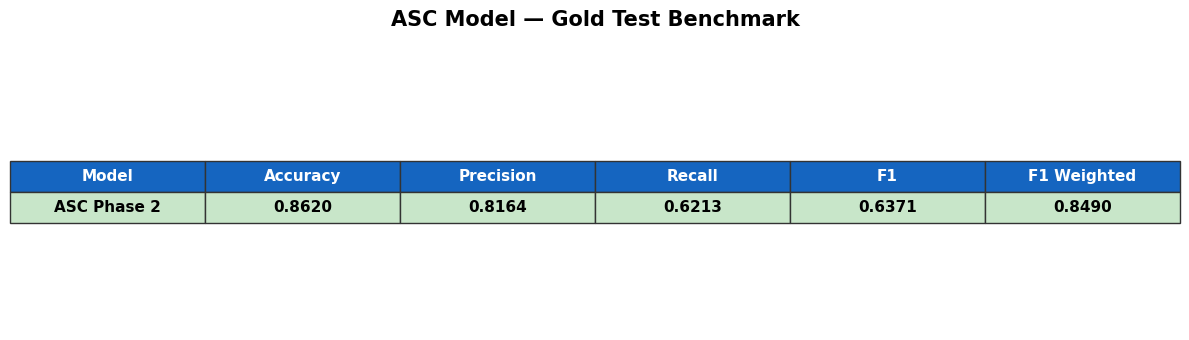

Saved: /content/drive/MyDrive/asc_phase2/outputs/benchmark_report/asc_model_benchmark_table.png


In [27]:
ASC_TABLE_PATH = f"{BENCHMARK_DIR}/asc_model_benchmark_table.png"

draw_metric_table(
    summary_df,
    title="ASC Model — Gold Test Benchmark",
    save_path=ASC_TABLE_PATH,
    highlight_row=0,
    figsize=(12, 3.5),
)

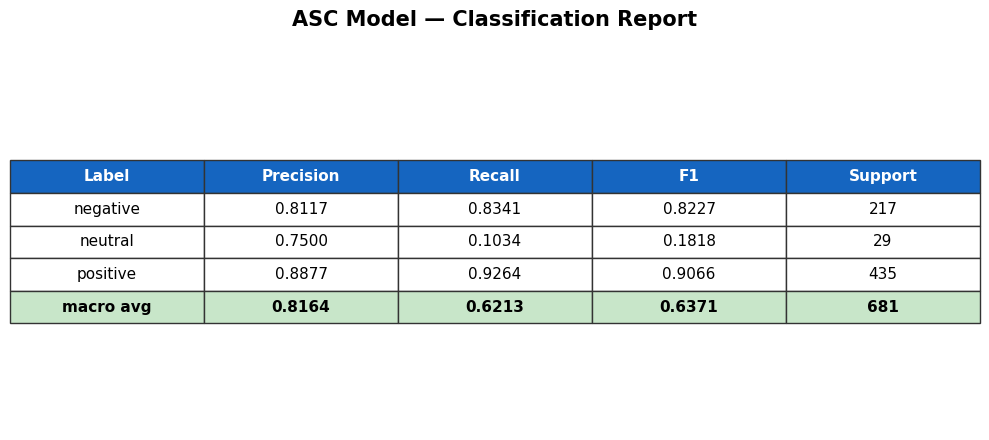

Saved: /content/drive/MyDrive/asc_phase2/outputs/benchmark_report/classification_report_table.png


In [29]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

class_rows = []

for label in target_names:
    class_rows.append({
        "Label": label,
        "Precision": report_dict[label]["precision"],
        "Recall": report_dict[label]["recall"],
        "F1": report_dict[label]["f1-score"],
        "Support": int(report_dict[label]["support"]),
    })

class_rows.append({
    "Label": "macro avg",
    "Precision": report_dict["macro avg"]["precision"],
    "Recall": report_dict["macro avg"]["recall"],
    "F1": report_dict["macro avg"]["f1-score"],
    "Support": int(report_dict["macro avg"]["support"]),
})

class_report_df = pd.DataFrame(class_rows)

CLASS_TABLE_PATH = f"{BENCHMARK_DIR}/classification_report_table.png"

draw_metric_table(
    class_report_df,
    title="ASC Model — Classification Report",
    save_path=CLASS_TABLE_PATH,
    highlight_row=len(class_report_df) - 1,
    figsize=(10, 4.5),
)

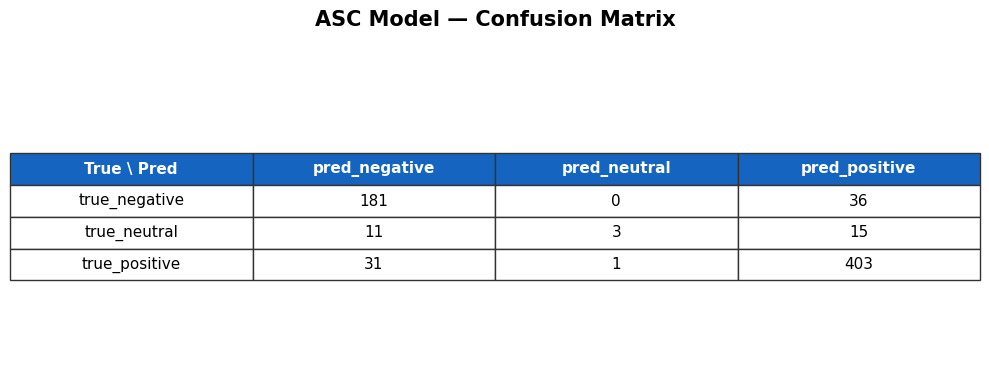

Saved: /content/drive/MyDrive/asc_phase2/outputs/benchmark_report/confusion_matrix_table.png


In [26]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=["true_negative", "true_neutral", "true_positive"],
    columns=["pred_negative", "pred_neutral", "pred_positive"],
)

CM_TABLE_PATH = f"{BENCHMARK_DIR}/confusion_matrix_table.png"

draw_metric_table(
    cm_df.reset_index().rename(columns={"index": "True \\ Pred"}),
    title="ASC Model — Confusion Matrix",
    save_path=CM_TABLE_PATH,
    highlight_row=None,
    figsize=(10, 4),
)